# 📊 Projeto Telecom X - ETL + EDA
Análise de Evasão de Clientes da empresa Telecom X.

In [1]:
# 📦 1. IMPORTAÇÃO DAS BIBLIOTECAS
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 📌 <b>Extracão e Normalização</b>

In [2]:
# 📁 2. EXTRAÇÃO DOS DADOS
with open("data/TelecomX_Data.json", encoding='utf-8') as f:
    data = json.load(f)

# Transformar para DataFrame
df = pd.json_normalize(data)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


## 🔧 <b>Transformação</b>

In [3]:
# 📊 4. ESTRUTURA E INFORMAÇÕES GERAIS
print("Dimensão:", df.shape)
df.info()


Dimensão: (7267, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       

In [4]:
# 📌 5. AJUSTES INICIAIS
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df['Churn'] = df['Churn'].replace('', np.nan)
df['Contas_Diarias'] = df['account.Charges.Monthly'] / 30

In [5]:
# 🔍 6. VERIFICAÇÃO DE VALORES AUSENTES
missing = df.isnull().sum()
missing[missing > 0]

Churn                    224
account.Charges.Total     11
dtype: int64

In [6]:
# 🔧 7. TRATAMENTO E PADRONIZAÇÃO
bin_cols = ['customer.Partner', 'customer.Dependents', 'account.PaperlessBilling']
for col in bin_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [7]:
# 8. ANÁLISE DESCRITIVA

df.describe(include='all')


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Contas_Diarias
count,7267,7043,7267,7267.000000,7267.000000,7267.000000,7267.000000,7267,7267,7267,...,7267,7267,7267,7267,7267,7267.000000,7267,7267.000000,7256.000000,7267.000000
unique,7267,2,2,NaN,NaN,NaN,NaN,2,3,3,...,3,3,3,3,3,NaN,4,NaN,NaN,NaN
top,0002-ORFBO,No,Male,NaN,NaN,NaN,NaN,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,NaN,Electronic check,NaN,NaN,NaN
freq,1,5174,3675,NaN,NaN,NaN,NaN,6560,3495,3198,...,3195,3582,2896,2870,4005,NaN,2445,NaN,NaN,NaN
mean,NaN,NaN,NaN,0.162653,0.484106,0.300124,32.346498,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.593230,NaN,64.720098,2280.634213,2.157337
std,NaN,NaN,NaN,0.369074,0.499782,0.458343,24.571773,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.491265,NaN,30.129572,2268.632997,1.004319
min,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,18.250000,18.800000,0.608333
25%,NaN,NaN,NaN,0.000000,0.000000,0.000000,9.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,35.425000,400.225000,1.180833
50%,NaN,NaN,NaN,0.000000,0.000000,0.000000,29.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,70.300000,1391.000000,2.343333
75%,NaN,NaN,NaN,0.000000,1.000000,1.000000,55.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,89.875000,3785.300000,2.995833


## 📊 <b>Contagem de Evasão por Variáveis Categóricas</b>

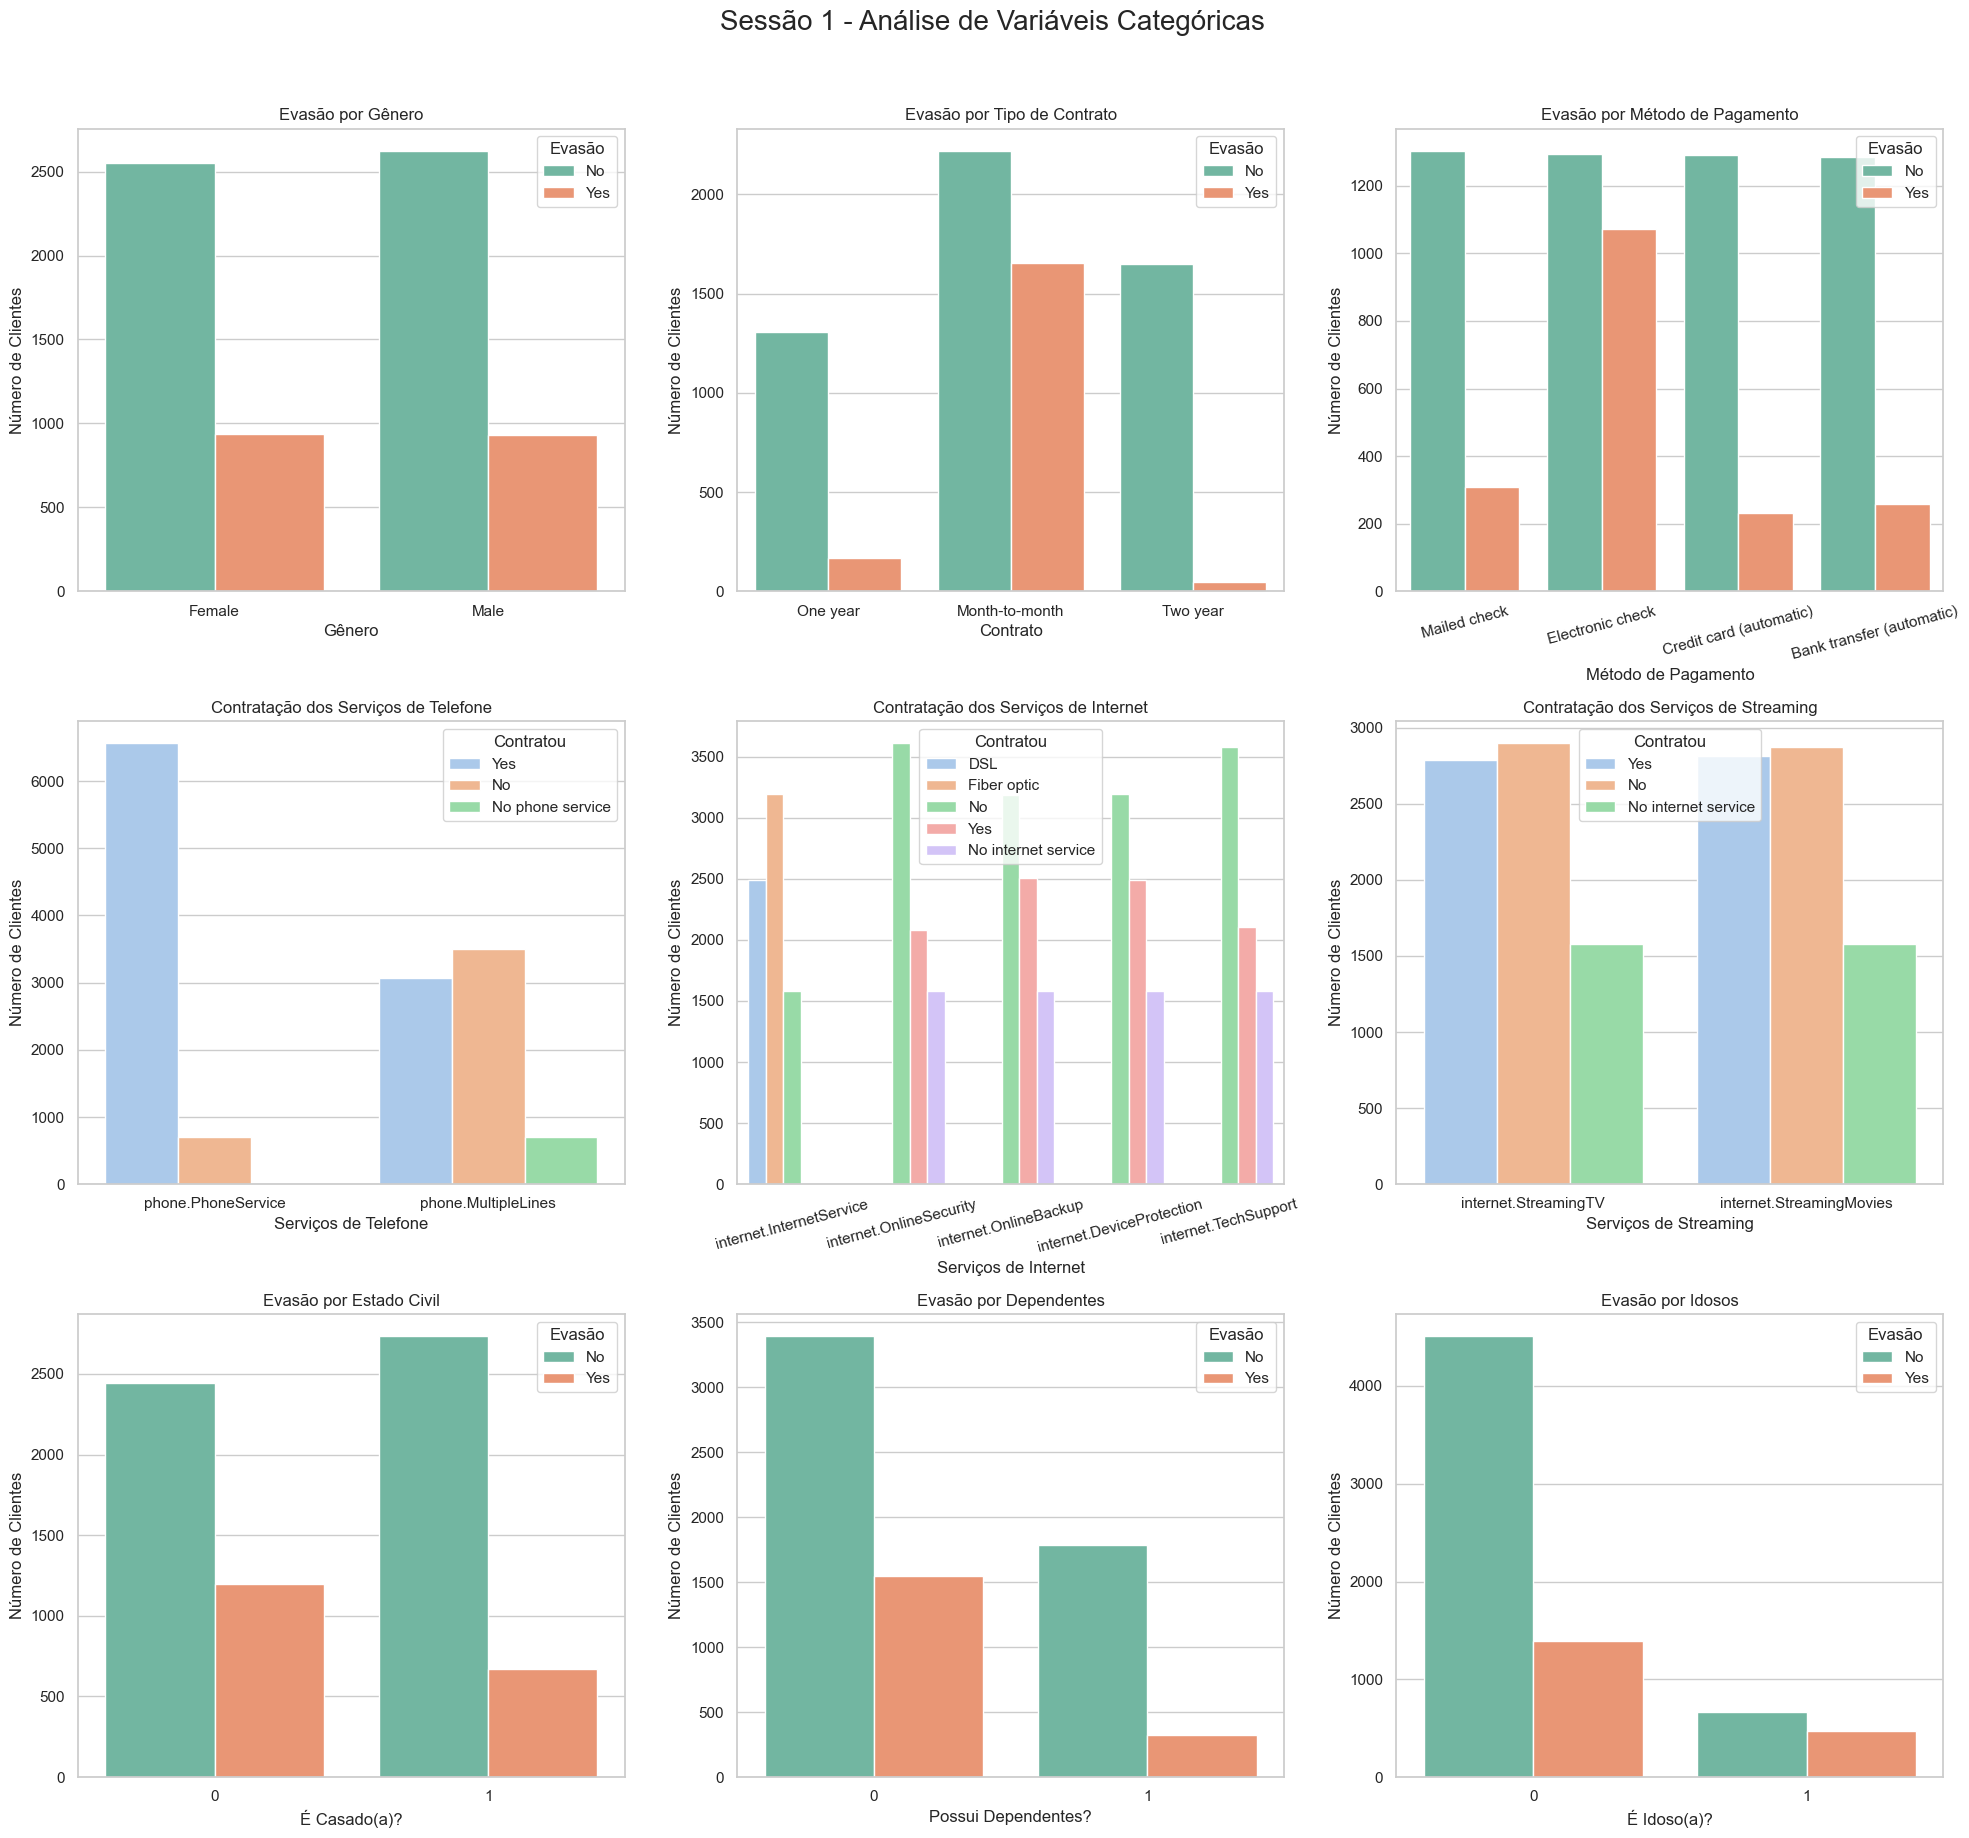

In [8]:
# Estilo gráfico
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (18, 14)

# ----------------------------------
# Parte 1: Gênero, Contrato, Pagamento
# ----------------------------------
fig, axs = plt.subplots(3, 3, figsize=(20, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1.1 Gênero
sns.countplot(data=df, x='customer.gender', hue='Churn', ax=axs[0,0], palette='Set2')
axs[0,0].set_title('Evasão por Gênero')
axs[0,0].set_xlabel('Gênero')
axs[0,0].set_ylabel('Número de Clientes')
axs[0,0].legend(title='Evasão')

# 1.2 Tipo de Contrato
sns.countplot(data=df, x='account.Contract', hue='Churn', ax=axs[0,1], palette='Set2')
axs[0,1].set_title('Evasão por Tipo de Contrato')
axs[0,1].set_xlabel('Contrato')
axs[0,1].set_ylabel('Número de Clientes')
axs[0,1].legend(title='Evasão')

# 1.3 Método de Pagamento
sns.countplot(data=df, x='account.PaymentMethod', hue='Churn', ax=axs[0,2], palette='Set2')
axs[0,2].set_title('Evasão por Método de Pagamento')
axs[0,2].set_xlabel('Método de Pagamento')
axs[0,2].set_ylabel('Número de Clientes')
axs[0,2].tick_params(axis='x', rotation=15)
axs[0,2].legend(title='Evasão')

# ----------------------------------
# Parte 2: Serviços de Telefone, Internet, Streaming
# ----------------------------------

# 1.4 Serviços de Telefone (2 variáveis)
servicos_telefone = ['phone.PhoneService', 'phone.MultipleLines']
df_telefone = df.melt(id_vars='Churn', value_vars=servicos_telefone, var_name='Serviço', value_name='Status')
sns.countplot(data=df_telefone, x='Serviço', hue='Status', ax=axs[1,0], palette='pastel')
axs[1,0].set_title('Contratação dos Serviços de Telefone')
axs[1,0].set_xlabel('Serviços de Telefone')
axs[1,0].set_ylabel('Número de Clientes')
axs[1,0].legend(title='Contratou')

# 1.5 Serviços de Internet (5 variáveis)
servicos_internet = ['internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport']
df_internet = df.melt(id_vars='Churn', value_vars=servicos_internet, var_name='Serviço', value_name='Status')
sns.countplot(data=df_internet, x='Serviço', hue='Status', ax=axs[1,1], palette='pastel')
axs[1,1].set_title('Contratação dos Serviços de Internet')
axs[1,1].set_xlabel('Serviços de Internet')
axs[1,1].set_ylabel('Número de Clientes')
axs[1,1].tick_params(axis='x', rotation=15)
axs[1,1].legend(title='Contratou')

# 1.6 Serviços de Streaming (2 variáveis)
servicos_streaming = ['internet.StreamingTV', 'internet.StreamingMovies']
df_streaming = df.melt(id_vars='Churn', value_vars=servicos_streaming, var_name='Serviço', value_name='Status')
sns.countplot(data=df_streaming, x='Serviço', hue='Status', ax=axs[1,2], palette='pastel')
axs[1,2].set_title('Contratação dos Serviços de Streaming')
axs[1,2].set_xlabel('Serviços de Streaming')
axs[1,2].set_ylabel('Número de Clientes')
axs[1,2].legend(title='Contratou')

# ----------------------------------
# Parte 3: Estado Civil, Dependentes, Idosos
# ----------------------------------

# 1.7 Casado
sns.countplot(data=df, x='customer.Partner', hue='Churn', ax=axs[2,0], palette='Set2')
axs[2,0].set_title('Evasão por Estado Civil')
axs[2,0].set_xlabel('É Casado(a)?')
axs[2,0].set_ylabel('Número de Clientes')
axs[2,0].legend(title='Evasão')

# 1.8 Dependentes
sns.countplot(data=df, x='customer.Dependents', hue='Churn', ax=axs[2,1], palette='Set2')
axs[2,1].set_title('Evasão por Dependentes')
axs[2,1].set_xlabel('Possui Dependentes?')
axs[2,1].set_ylabel('Número de Clientes')
axs[2,1].legend(title='Evasão')

# 1.9 Idosos
sns.countplot(data=df, x='customer.SeniorCitizen', hue='Churn', ax=axs[2,2], palette='Set2')
axs[2,2].set_title('Evasão por Idosos')
axs[2,2].set_xlabel('É Idoso(a)?')
axs[2,2].set_ylabel('Número de Clientes')
axs[2,2].legend(title='Evasão')

plt.suptitle('Sessão 1 - Análise de Variáveis Categóricas', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()


## 📊 <b>Contagem de Evasão por Variáveis Numéricas</b>

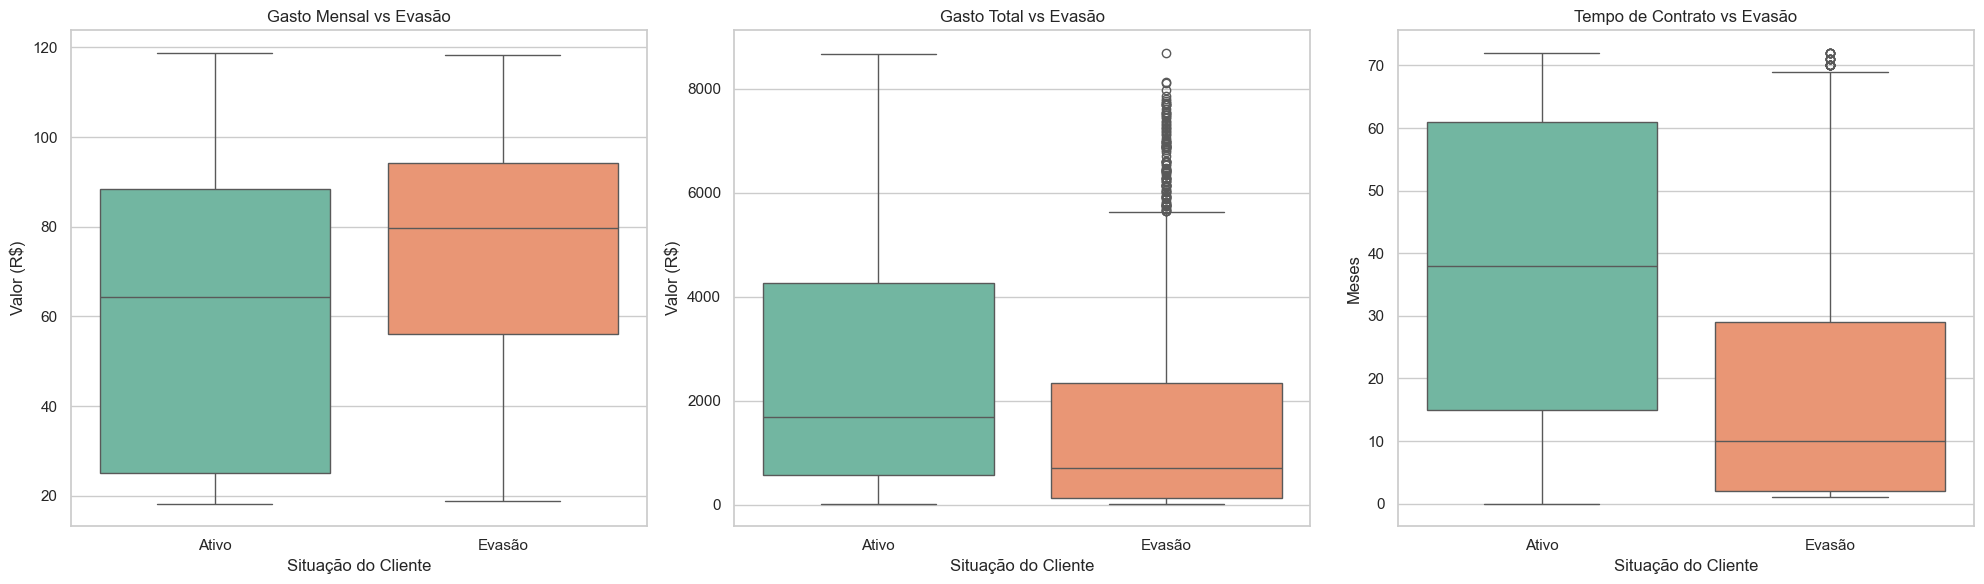

In [9]:
# Garantir o uso do DataFrame correto
# df = df.copy()

# Tradução da coluna 'Churn'
df['Churn'] = df['Churn'].map({'Yes': 'Evasão', 'No': 'Ativo'})

# Conversão segura da coluna 'Charges.Total'
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Estilo e configuração
sns.set(style='whitegrid')
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

# Gráfico 1: Gasto Mensal
sns.boxplot(x='Churn', y='account.Charges.Monthly', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Gasto Mensal vs Evasão')
axes[0].set_ylabel('Valor (R$)')
axes[0].set_xlabel('Situação do Cliente')

# Gráfico 2: Gasto Total
sns.boxplot(x='Churn', y='account.Charges.Total', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Gasto Total vs Evasão')
axes[1].set_ylabel('Valor (R$)')
axes[1].set_xlabel('Situação do Cliente')

# Gráfico 3: Tempo de Contrato
sns.boxplot(x='Churn', y='customer.tenure', data=df, palette='Set2', ax=axes[2])
axes[2].set_title('Tempo de Contrato vs Evasão')
axes[2].set_ylabel('Meses')
axes[2].set_xlabel('Situação do Cliente')

plt.tight_layout()
plt.show()



## 📊 <b>Análise de Correlação</b>

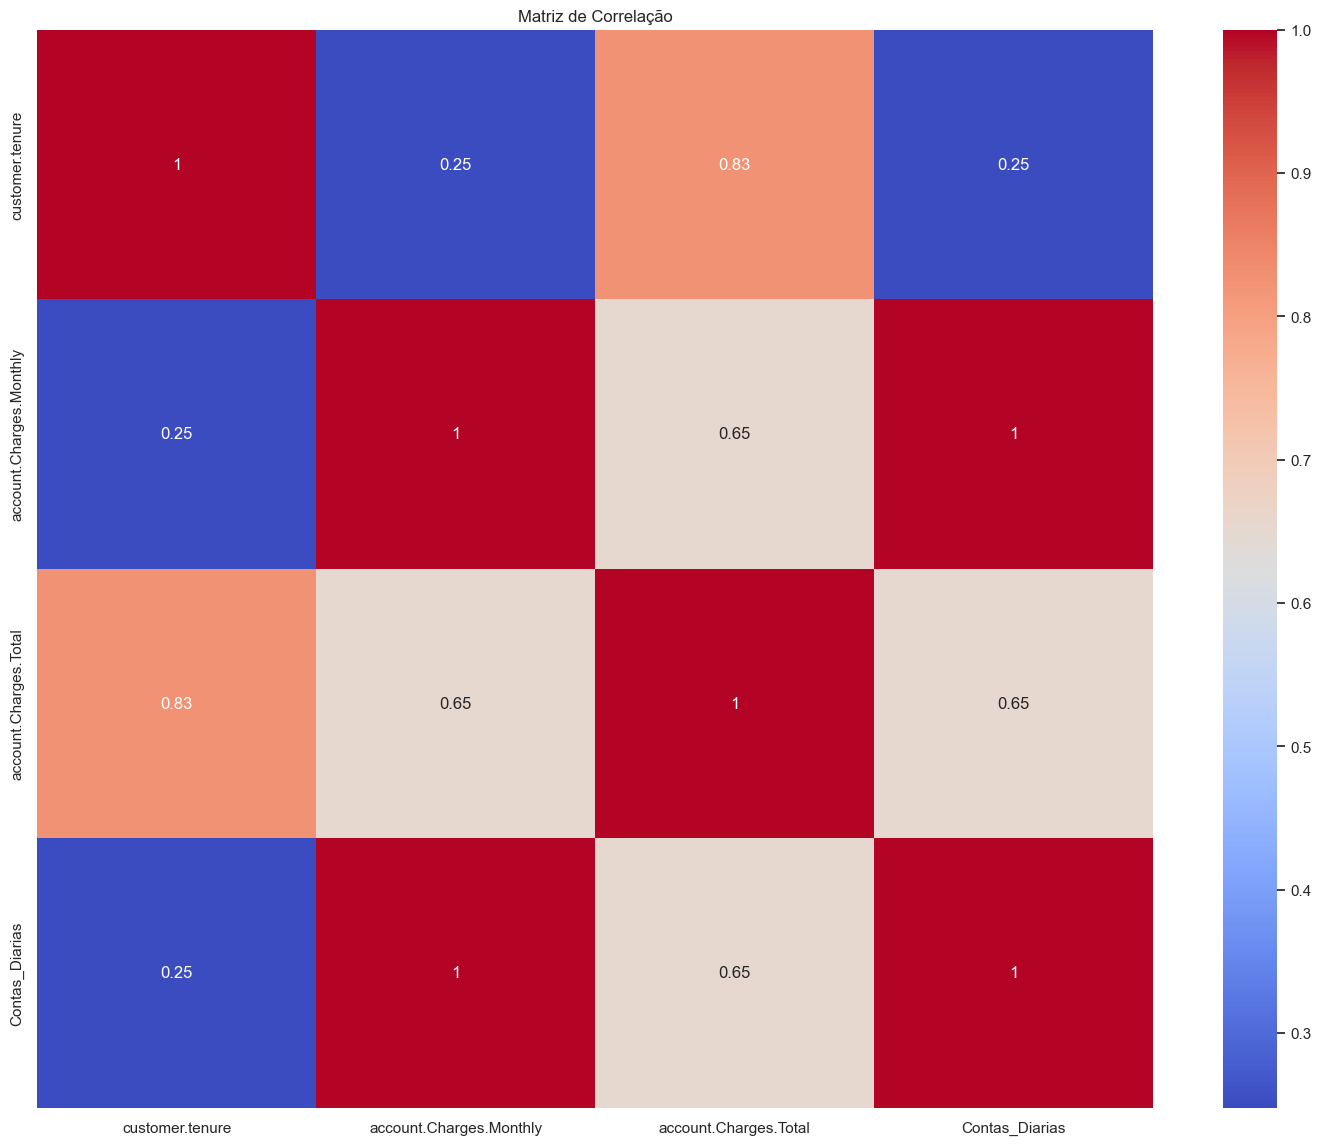

In [10]:
# 🔗 9. CORRELAÇÕES (variáveis numéricas)
num_cols = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'Contas_Diarias']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de Correlação")
plt.show()

<hr>

Salvando o BD, para o Telecom X - Parte 2

In [11]:
df.to_csv("data/dados_tratados.csv", index=False) 

In [13]:
df2 = pd.read_csv("data/dados_tratados.csv")  
df2

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Contas_Diarias
0,0002-ORFBO,Ativo,Female,0,1,1,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,Ativo,Male,0,0,0,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Evasão,Male,0,0,0,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Evasão,Male,1,1,0,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Evasão,Female,1,1,0,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,Ativo,Female,0,0,0,13,Yes,No,DSL,...,No,Yes,No,No,One year,0,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Evasão,Male,0,1,0,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,1,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,Ativo,Male,0,0,0,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,1,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,Ativo,Male,0,1,1,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,0,Mailed check,67.85,4627.65,2.261667


---

## 📝 <b>Relatório Final</b>
### 🎯 <b>Objetivo</b>
Este projeto tem como objetivo realizar uma análise exploratória dos dados da empresa **Telecom X**, que enfrenta uma alta taxa de **evasão de clientes (Churn)**. A análise tem o propósito de identificar padrões e comportamentos que possam estar associados ao desligamento dos clientes, auxiliando assim a equipe de Data Science no desenvolvimento de estratégias e modelos preditivos que contribuam para a **retenção de clientes**.

### 🔍 <b>Etapas Realizadas</b>
#### 1. Limpeza e Tratamento de Dados

O processo de ETL foi iniciado com a **extração dos dados** em formato JSON de uma API hospedada no GitHub. Após a importação, os dados passaram por uma etapa de normalização para que as colunas aninhadas fossem transformadas em um formato tabular adequado.

As principais etapas do tratamento incluíram:

- **Renomeação e tradução** dos nomes das colunas para o idioma português (Brasil);
- Conversão de colunas binárias para valores categóricos "Sim"/"Não";
- Conversão de campos numéricos;
- Criação da coluna `Contas_Diarias` com base na divisão do valor mensal por 30 dias;
- Criação da coluna `Qtd_Servicos` com a contagem dos serviços contratados por cliente.

#### 2. Análise Exploratória de Dados (EDA)

A análise foi dividida em três grandes sessões:

##### Sessão 1: Variáveis Categóricas

Foram exploradas variáveis como:

- Sexo, tipo de contrato, método de pagamento;
- Serviços de telefone, internet e streaming;
- Estado civil, dependentes e se é idoso.

Cada gráfico apresentou os percentuais de evasão por categoria, com **cores distintas e explicações visuais**.

#### Sessão 2: Variáveis Numéricas

Foram analisadas:

- Gasto Mensal
- Gasto Total
- Tempo de Contrato

Essas variáveis foram visualizadas por meio de boxplots, segmentando clientes que evadiram ou não.

#### Sessão 3: Correlação

Foi utilizada uma **matriz de correlação (heatmap)** para variáveis numéricas:

- Tempo de contrato, gasto mensal, gasto total e contas diárias.

### 📊 <b>Insights</b>
Com base nas análises realizadas, os seguintes padrões foram identificados:

- Clientes com **contratos mensais** têm maior propensão à evasão;
- **Pagamentos eletrônicos automáticos** estão entre os métodos com maior churn;
- Clientes com **menor tempo de contrato**, **gasto total mais baixo** e **poucos serviços contratados** são mais propensos a sair;
- Serviços como **segurança online, suporte técnico e múltiplas linhas** estão associados a uma **menor taxa de evasão**;
- Pessoas **sem dependentes ou não casadas** tendem a evadir mais.

### ✅ <b>Recomendações</b>
Com base nos insights encontrados, recomendamos:

- Oferecer **benefícios para contratos anuais ou bienais**, com descontos ou bônus;
- Reforçar **programas de fidelidade** para novos clientes;
- Criar **alertas internos de churn** para clientes com perfis de alto risco (baixo gasto, pouco tempo de contrato, poucos serviços);
- Investir na **divulgação de serviços adicionais** como backup, segurança e suporte técnico;
- Promover ações específicas para **clientes solteiros ou sem dependentes**, como planos familiares ou personalizados.

---

Essas ações poderão ser complementadas com o uso de modelos preditivos de churn e dashboards interativos em futuras etapas do projeto.